# Recurrent Neural Networks
https://github.com/saqemlas/deep-learning-specialization/blob/main/5_SequenceModels/week_1/Assignment/Building_a_Recurrent_Neural_Network_Step_by_Step.ipynb

In [1]:
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense

2026-04-20 23:45:53.437122: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 23:45:53.467530: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 23:45:54.240172: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
max_features = 10000 # Number of words to consider as features
maxlen = 500 # Cuts off texts after this number of words (among the max_features most common words)
batch_size = 32 

In [3]:
start_char = 1
oov_char = 2 # Out of vocabulary character
index_from = 3 # Index actual words with this index and higher

In [4]:
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features, maxlen=maxlen)#, start_char=start_char, oov_char=oov_char, index_from=index_from)
# Load training and test data, keeping only the top max_features most frequent words, and cutting off texts after maxlen words (among the max_features most common words)

In [5]:
input_train[3:]

array([list([1, 249, 1323, 7, 61, 113, 10, 10, 13, 1637, 14, 20, 56, 33, 2401, 18, 457, 88, 13, 2626, 1400, 45, 3171, 13, 70, 79, 49, 706, 919, 13, 16, 355, 340, 355, 1696, 96, 143, 4, 22, 32, 289, 7, 61, 369, 71, 2359, 5, 13, 16, 131, 2073, 249, 114, 249, 229, 249, 20, 13, 28, 126, 110, 13, 473, 8, 569, 61, 419, 56, 429, 6, 1513, 18, 35, 534, 95, 474, 570, 5, 25, 124, 138, 88, 12, 421, 1543, 52, 725, 6397, 61, 419, 11, 13, 1571, 15, 1543, 20, 11, 4, 2, 5, 296, 12, 3524, 5, 15, 421, 128, 74, 233, 334, 207, 126, 224, 12, 562, 298, 2167, 1272, 7, 2601, 5, 516, 988, 43, 8, 79, 120, 15, 595, 13, 784, 25, 3171, 18, 165, 170, 143, 19, 14, 5, 7224, 6, 226, 251, 7, 61, 113]),
       list([1, 778, 128, 74, 12, 630, 163, 15, 4, 1766, 7982, 1051, 2, 32, 85, 156, 45, 40, 148, 139, 121, 664, 665, 10, 10, 1361, 173, 4, 749, 2, 16, 3804, 8, 4, 226, 65, 12, 43, 127, 24, 2, 10, 10]),
       list([1, 6740, 365, 1234, 5, 1156, 354, 11, 14, 5327, 6638, 7, 1016, 2, 5940, 356, 44, 4, 1349, 500, 746, 5, 200,

In [6]:
len(input_train[3])

147

In [7]:
input_train.max()

[1,
 9995,
 2,
 7,
 2208,
 7335,
 3135,
 4173,
 3783,
 509,
 1683,
 4702,
 2,
 2,
 6,
 201,
 7,
 6415,
 687,
 2,
 2,
 7,
 6387,
 548,
 139,
 7583,
 295,
 34,
 4485,
 5302,
 2,
 2,
 2,
 7,
 2,
 2,
 146,
 24,
 1017,
 2282,
 133,
 21,
 4,
 1591,
 3113,
 786,
 2,
 16,
 125,
 4,
 2,
 9790,
 2039,
 137,
 267,
 2,
 5,
 2,
 120,
 2024,
 980,
 2,
 1248,
 5666,
 727,
 1405,
 6879,
 1060,
 6442,
 18,
 2,
 1461,
 2,
 1883,
 445,
 109,
 5369,
 3696,
 33,
 236,
 786,
 5580,
 7994,
 8,
 2,
 2,
 103,
 2,
 98,
 11,
 2,
 1461,
 24,
 66,
 351,
 1461,
 165,
 116,
 17,
 2545,
 18,
 6717,
 8694,
 5514,
 980,
 2545,
 165,
 734,
 18,
 2311,
 52,
 84,
 157,
 18,
 7232,
 11,
 661,
 8,
 607,
 3531,
 223,
 1066,
 445,
 9236,
 996,
 8,
 2898,
 4931,
 8,
 5526,
 8316,
 7880,
 154,
 378,
 459,
 18,
 6942,
 632,
 5,
 79,
 2024,
 18,
 68,
 4918,
 813,
 2456,
 2,
 17,
 840,
 4807,
 3854,
 23,
 136,
 159,
 5770,
 852,
 1698,
 632,
 7708,
 7993,
 1003,
 1372,
 5747,
 2,
 7,
 5840,
 5408,
 11,
 7200,
 120,
 4682,
 7,
 2,


In [8]:
word_index = imdb.get_word_index()
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [9]:
# Reverse the word index to obtain a dict mapping indices to words
# And add 'index_from' to indices to sync with 'x_train'
inverted_word_index = dict((i + index_from, word) for (word, i) in word_index.items())

# Update inverted_word_index to include 'start_char and oov_char
inverted_word_index[start_char] = "[START]"
inverted_word_index[oov_char] = "[OOV]"
# Decode the first sequence in the dataset
decoded_sequence = ' '.join(inverted_word_index[i] for i in input_train[3])
decoded_sequence

"[START] worst mistake of my life br br i picked this movie up at target for 5 because i figured hey it's sandler i can get some cheap laughs i was wrong completely wrong mid way through the film all three of my friends were asleep and i was still suffering worst plot worst script worst movie i have ever seen i wanted to hit my head up against a wall for an hour then i'd stop and you know why because it felt damn good upon bashing my head in i stuck that damn movie in the [OOV] and watched it burn and that felt better than anything else i've ever done it took american psycho army of darkness and kill bill just to get over that crap i hate you sandler for actually going through with this and ruining a whole day of my life"

In [10]:
input_train = pad_sequences(input_train, maxlen=maxlen)
input_test = pad_sequences(input_test, maxlen=maxlen)
# Use beforehand selected maximum length to the consequent data of the training and test sets. Sequences longer than this will be truncated, and sequences shorter will be padded with zeros at the beginning.

In [11]:
input_train[3:]

array([[   0,    0,    0, ...,    7,   61,  113],
       [   0,    0,    0, ...,    2,   10,   10],
       [   0,    0,    0, ...,   55,   52, 1901],
       ...,
       [   0,    0,    0, ...,    4, 3586,    2],
       [   0,    0,    0, ...,   12,    9,   23],
       [   0,    0,    0, ...,  204,  131,    9]], dtype=int32)

In [12]:
len(input_train[0])

500

In [13]:
input_train[3]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [14]:
model = Sequential()
# Create empty Sequential model

# Add an Embedding layer for words conversion with the following arguments:
# - max_features: the size of the vocabulary, i.e. maximum integer index + 1
# - 32: the dimension of the dense embedding

# Add Empbedding layer for words conversion 
model.add(Embedding(max_features, 32))
# Parameter: number of words to consider as features (vocabulary size), dimension of the dense embedding (size of the embedding vector for each word)



# Add SimpleRNN layer with 32 units
model.add(SimpleRNN(32))
# Parameter: number of units (size of the hidden state)



# Add a Dense classifier on top with a single unit and sigmoid activation
model.add(Dense(1, activation='sigmoid'))
# Parameters: number of units (output dimension), activation function (sigmoid for binary classification)

2026-04-20 23:45:56.463559: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.build(input_shape=(None, maxlen))

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# len(model.layers[0].weights[0][0])
model.layers[0].weights[0][0] # one vector of length 32 per word -> this is learnt

<tf.Tensor: shape=(32,), dtype=float32, numpy=
array([ 0.01467425,  0.02665532,  0.0132365 ,  0.0247479 , -0.00807192,
        0.04775292, -0.04504299,  0.03143351, -0.042145  , -0.01221193,
       -0.02614422,  0.04634038,  0.0381681 , -0.00084618,  0.02461282,
       -0.02647191, -0.04912687, -0.02617362,  0.02108618, -0.004611  ,
        0.04000861,  0.0142883 , -0.01286571, -0.03882396,  0.02407935,
       -0.0180495 , -0.00827352,  0.00302477, -0.03232085,  0.02736134,
        0.02562909,  0.04659723], dtype=float32)>

In [18]:
history = model.fit(input_train, y_train, epochs=5, batch_size=128, validation_split=0.3)
# Launch model learning for train data and 5 epochs, with a batch size of 128, and using 30% of the data for validation. Store training history in 'history' variable.

Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - acc: 0.5878 - loss: 0.6606 - val_acc: 0.7515 - val_loss: 0.5346
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - acc: 0.7892 - loss: 0.4674 - val_acc: 0.7882 - val_loss: 0.4593
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - acc: 0.8553 - loss: 0.3462 - val_acc: 0.8064 - val_loss: 0.4437
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - acc: 0.8836 - loss: 0.2854 - val_acc: 0.7924 - val_loss: 0.4523
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - acc: 0.9188 - loss: 0.2126 - val_acc: 0.7946 - val_loss: 0.5013


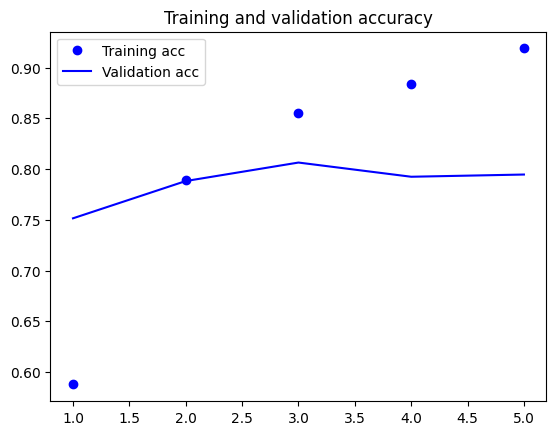

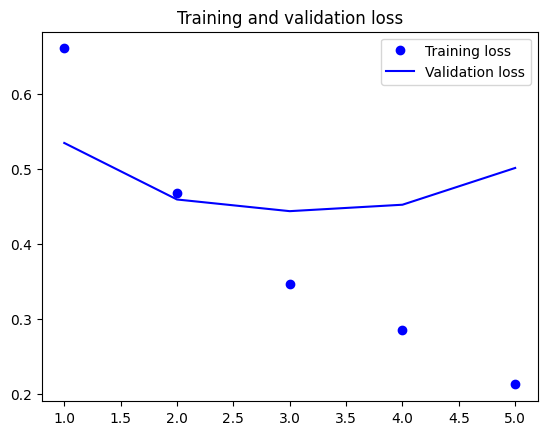

In [19]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# Embedding
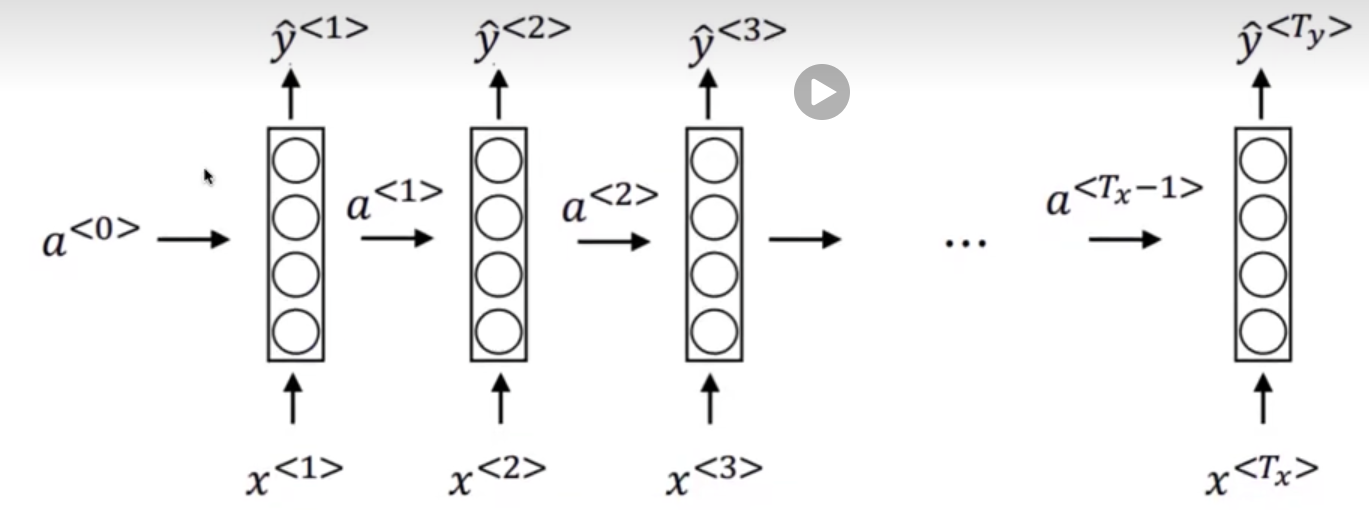

In [20]:
# Let's take a detailed look at how the Embedding layer and the SimpleRNN layer can be implemented
import numpy as np

# Custom implementation of the Embedding layer
class CustomEmbedding:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        # Initialize the embedding matrix with random values
        self.embeddings_matrix = np.random.randn(input_dim, output_dim)

    def forward(self, input_indices):
        # Retrieve embeddings for the input sequence of word indices
        embeddings = [self.embeddings_matrix[word_index] for word_index in input_indices]
        return np.array(embeddings)

# RNN and hidden layers

## Sequence classification

In [21]:
class CustomSimpleRNN:
    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        # Initialize weights for the inpout-to_hidden and hidden-to-hidden connections, and the bias
        self.Wx = np.random.randn(input_dim, hidden_dim)  # Weights for input
        self.Wh = np.random.randn(hidden_dim, hidden_dim)  # Weights for hidden state
        self.b = np.zeros((1, hidden_dim,))  # Bias
        # Initialize the hidden state to None
        self.h = None   

    def forward(self, input_sequence):
        # 
        self.h = np.zeros((1, self.hidden_dim))  # Initial hidden state
        # Iterate through each time step in the input sequence
        for input_t in input_sequence:
            self.h = np.tanh(np.dot(input_t, self.Wx) + np.dot(self.h, self.Wh) + self.b)
        return self.h

In [22]:
# Custom implementation of the Dense layer - for a sequence classification task
class CustomDense:
    def __init__(self, input_dim, output_dim, activation):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.activation = activation

        # Initialize weights and bias for the dense layer
        self.W = np.random.randn(input_dim, output_dim)  # Weights
        self.b = np.zeros((1, output_dim))  # Bias

    def forward(self, input_vector):
        # Compute the output of the dense layer using a linear transformation followed by the specified activation function
        z = np.dot(input_vector, self.W) + self.b  # Linear transformation
        if self.activation == 'sigmoid':
            output = 1 / (1 + np.exp(-z))  # Sigmoid activation function
        elif self.activation == 'relu':
            output = np.maximum(0, z)  # ReLU activation function       
        
        return output

In [23]:
# Instantiate the custom layers
custom_embedding_layer = CustomEmbedding(input_dim=max_features, output_dim=32)
custom_simple_rnn_layer = CustomSimpleRNN(input_dim=32, hidden_dim=32)
custom_dense_layer = CustomDense(input_dim=32, output_dim=1, activation='sigmoid')

In [24]:
input_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [25]:
# Forward pass through cutom layers for the first training example

embedded_sequence = custom_embedding_layer.forward(input_train[0])  # Get the embeddings for the input sequence
len(embedded_sequence)  # Length of the embedded sequence (should be maxlen) each word incoded into a 32-element vector

500

In [26]:
rnn_output = custom_simple_rnn_layer.forward(embedded_sequence)  # Get the output of the SimpleRNN layer
rnn_output

array([[ 0.99999977,  0.99999614, -0.99999736, -0.46049892, -0.99999997,
         0.99777994, -1.        , -0.99964592,  1.        , -0.99910713,
        -1.        , -1.        ,  1.        ,  0.99974154, -0.86855034,
         1.        , -0.69786407, -1.        ,  0.99990214,  1.        ,
        -0.99999999, -1.        , -0.99251288,  1.        , -0.99954897,
         0.36635768,  0.96647046,  0.99999763, -0.99999999, -1.        ,
         0.79755045,  1.        ]])

In [27]:
predictions = custom_dense_layer.forward(rnn_output)  # Get the final prediction from the Dense layer
predictions

array([[0.00804647]])

In [28]:
loss = predictions - y_train[0]  # Compute a simple loss (difference between prediction and true label)
loss[0]

array([-0.99195353])

In [29]:
custom_simple_rnn_layer.Wh

array([[-0.14128936, -2.05751863,  0.79871323, ..., -1.07527764,
        -0.06419371,  0.28310391],
       [ 0.77430069, -1.76566605,  1.27768681, ...,  0.5291796 ,
        -0.46671323, -0.25553399],
       [ 1.10941298,  0.85757115,  0.42467944, ..., -1.2018212 ,
         0.33407768,  0.74631595],
       ...,
       [-0.88546283,  1.27451504, -0.9159779 , ..., -1.29682165,
        -1.71083915, -0.09301656],
       [ 1.3708351 ,  1.17529764, -0.51669488, ..., -0.47726202,
         0.45703259, -0.27198887],
       [ 0.98860524, -2.18869811, -0.6435839 , ...,  0.46134262,
        -0.08273001, -1.31449594]])

# Token classification

In [30]:
import numpy as np
# For comparison
"""
class CustomSimpleRNN:
    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.Wx = np.random.randn(input_dim, hidden_dim)
        self.Wh = np.random.randn(hidden_dim, hidden_dim)
        self.b = np.zeros((1, hidden_dim))
        self.h = None

    def forward(self, input_sequence):
        # Initialize hidden state with zeros
        self.h = np.zeros((1, self.hidden_dim))
        for input_t in input_sequence:
            self.h = np.tanh(np.dot(input_t, self.Wx) + np.dot(self.h, self.Wh) + self.b)
        return self.h

"""


class CustomSimpleRNN:
    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.Wx = np.random.randn(input_dim, hidden_dim)
        self.Wh = np.random.randn(hidden_dim, hidden_dim)
        self.b = np.zeros((1, hidden_dim))
        self.h = None

    def forward(self, input_sequence):
        self.h = np.zeros((len(input_sequence), self.hidden_dim))
        for t in range(len(input_sequence)):
            self.h[t] = np.tanh(np.dot(input_sequence[t], self.Wx) + np.dot(self.h[t-1], self.Wh) + self.b)
        return self.h

In [31]:
class CustomDense:
    def __init__(self, input_dim, output_dim, activation):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.activation = activation
        self.W = np.random.randn(input_dim, output_dim)
        self.b = np.zeros((1, output_dim))

    def forward(self, input_vector):
        z = np.dot(input_vector, self.W) + self.b
        if self.activation == 'sigmoid':
            output = 1 / (1 + np.exp(-z))
        elif self.activation == 'relu':
            output = np.maximum(0, z)
        return output
    
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Subtract max for numerical stability
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def softmax_output(self, input_vector):
        z = np.dot(input_vector, self.W) + self.b
        return self.softmax(z)

In [32]:
# Instantiating the custom layers
custom_embedding_layer = CustomEmbedding(input_dim=max_features, output_dim=32)
custom_simple_rnn_layer = CustomSimpleRNN(input_dim=32, hidden_dim=32)

# Output dimension is set to the number of tokens in the input sequence (maxlen) for sequence-to-sequence tasks, or 1 for sequence classification tasks
num_classes = 2  # Asuuming 'maxlen' is the maximum length of the input sequence, and we are doing a sequence classification task with 2 classes (binary classification)
custom_dense_layer = CustomDense(input_dim=32, output_dim=num_classes, activation='sigmoid')

# Forward pass through custom layers for the first training example
embedded_sequence = custom_embedding_layer.forward(input_train[0])  # Get the embeddings for the input sequence
                                          

In [33]:
rnn_output = custom_simple_rnn_layer.forward(embedded_sequence)  # Get the output of the SimpleRNN layer
rnn_output[0]

array([-0.99984283,  0.74134449, -0.99195765,  0.99998178,  0.99983351,
        0.94912104,  1.        ,  0.93924235,  0.99259636,  0.43355565,
       -0.9994061 , -0.99991927,  0.54812606, -0.99974719, -0.99927385,
       -0.99998213,  0.99982629,  1.        ,  0.9999074 ,  0.99824081,
       -0.99862864,  0.98224974,  0.99995784,  0.9925827 ,  0.99999965,
       -0.78800577,  0.99997858, -0.99837673, -0.99939617, -0.99999956,
       -0.99741577,  0.97234688])

In [34]:
len(rnn_output)

500

In [35]:
len(rnn_output[0])

32

In [36]:
predictions = custom_dense_layer.forward(rnn_output)  # Get the final prediction from the Dense layer
predictions

array([[7.72059794e-01, 3.56447140e-01],
       [8.15859229e-01, 7.35729135e-03],
       [9.30371617e-01, 1.08651220e-02],
       [8.59769069e-01, 4.86638468e-04],
       [9.75375720e-01, 1.77032838e-02],
       [9.13848303e-01, 1.86205107e-03],
       [8.36745287e-01, 7.93138099e-03],
       [7.14773260e-01, 3.90044068e-04],
       [9.78320348e-01, 1.77634631e-02],
       [9.10495592e-01, 2.30951832e-03],
       [7.90335033e-01, 7.16070490e-03],
       [6.86200482e-01, 4.54913059e-04],
       [9.77723465e-01, 1.75531115e-02],
       [9.15457681e-01, 2.34722098e-03],
       [7.96070056e-01, 7.21120533e-03],
       [6.92784671e-01, 4.43823124e-04],
       [9.77718138e-01, 1.75405830e-02],
       [9.15234106e-01, 2.34448802e-03],
       [7.96419512e-01, 7.21915021e-03],
       [6.92642975e-01, 4.43537244e-04],
       [9.77727298e-01, 1.75442105e-02],
       [9.15181555e-01, 2.34421105e-03],
       [7.96305987e-01, 7.21769179e-03],
       [6.92554300e-01, 4.43715826e-04],
       [9.777265

# Text generation

In [37]:
class CustomSimpleRNNGeneration:
    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.Wx = np.random.randn(input_dim, hidden_dim)
        self.Wh = np.random.randn(hidden_dim, hidden_dim)
        self.b = np.zeros((1, hidden_dim))
        self.h = None

    def forward(self, input_sequence):
        self.h = np.zeros((1, self.hidden_dim))
        for input_t in input_sequence:
            self.h[0] = np.tanh(np.dot(input_t, self.Wx) + np.dot(self.h, self.Wh) + self.b)
        return self.h
    
# Instantiate the custom layers for sequence generation
custom_embedding_layer_gen = CustomEmbedding(input_dim=max_features, output_dim=32)
custom_simple_rnn_layer_gen = CustomSimpleRNNGeneration(input_dim=32, hidden_dim=32)
custom_dense_layer_gen = CustomDense(input_dim=32, output_dim=max_features, activation='softmax')
# Output dimension is set to vocabulary size, representing the probability distribution over the next word in the sequence
vocab_size = 10000 # Example vocabulary size for sequence generation task
custom_dense_layer_gen = CustomDense(input_dim=32, output_dim=vocab_size, activation='softmax')

# Forward pass through custom layers for sequence generation
embedded_sequence_gen = custom_embedding_layer_gen.forward(input_train[0])  # Get the embeddings for the input sequence
                                     

In [38]:
rnn_output_gen = custom_simple_rnn_layer_gen.forward(embedded_sequence_gen)  # Get the output of the SimpleRNN layer
rnn_output_gen

array([[ 0.84962994, -0.72355368, -1.        ,  0.99999491, -0.99999965,
        -0.98845412, -0.99293202,  0.99999939,  0.96604542, -1.        ,
         0.99999979,  1.        ,  0.99998681,  0.8484807 , -0.22614921,
        -1.        , -1.        ,  0.77833208, -0.16205233, -0.99999936,
        -1.        ,  0.98118986,  0.99996945,  1.        ,  1.        ,
        -1.        ,  0.99356193, -1.        ,  0.99995217,  0.99999978,
         0.9913467 , -0.99999999]])

In [39]:
predictions_gen = custom_dense_layer_gen.softmax_output(rnn_output_gen[-1])  # Get the final prediction from the Dense layer using the last hidden state of the RNN for sequence generation
predictions_gen 


array([[2.61953513e-09, 1.20394244e-12, 6.58289723e-10, ...,
        3.34532091e-09, 3.00627922e-11, 3.58187209e-10]])

In [40]:
# Assuming 'start_sequence' is a seed sequence to start the generation process, we can implement a simple loop to generate a sequence of words based on the model's predictions. Here's an example of how this can be done:
start_sequence = 'hello'

# Initialize the generated text with the seed sequence
generated_text = [start_sequence]

# Set number of words to generate
num_words_to_generate = 10

# Generate text character by character (or word by word, depending on the tokenization) based on the model's predictions
for _ in range(num_words_to_generate):
    # Convert the current generated text to input sequence
    input_sequence = [word_index[char] for char in generated_text]
    print(f"Input sequence: {input_sequence}")
    input_sequence = np.array(input_sequence)  # Keep a 1D index sequence for the custom layers

    # Forward pass through the custom layers
    embedded_sequence = custom_embedding_layer_gen.forward(input_sequence)  # Get the embeddings
    rnn_output = custom_simple_rnn_layer_gen.forward(embedded_sequence)  # Get the output of the SimpleRNN layer
    predictions = custom_dense_layer_gen.softmax_output(rnn_output)  # Get the prediction for the next word

    # Sample the next character/word based on the output distribution
    next_char_index = np.argmax(predictions[-1])  # Get the index of the word with the highest probability
    next_char = inverted_word_index[next_char_index]  # Convert index back to word

    # Append the predicted word to the generated text
    generated_text.append(next_char)

print("Generated text:", generated_text)

Input sequence: [4822]
Input sequence: [4822, 6510]
Input sequence: [4822, 6510, 2960]
Input sequence: [4822, 6510, 2960, 4584]
Input sequence: [4822, 6510, 2960, 4584, 6403]
Input sequence: [4822, 6510, 2960, 4584, 6403, 3320]
Input sequence: [4822, 6510, 2960, 4584, 6403, 3320, 3354]
Input sequence: [4822, 6510, 2960, 4584, 6403, 3320, 3354, 5313]
Input sequence: [4822, 6510, 2960, 4584, 6403, 3320, 3354, 5313, 8952]
Input sequence: [4822, 6510, 2960, 4584, 6403, 3320, 3354, 5313, 8952, 822]
Generated text: ['hello', 'moe', 'essential', 'steel', 'biting', 'library', 'fashioned', 'absurdity', 'amoral', 'gone', 'thompson']


# Encoder-decoder

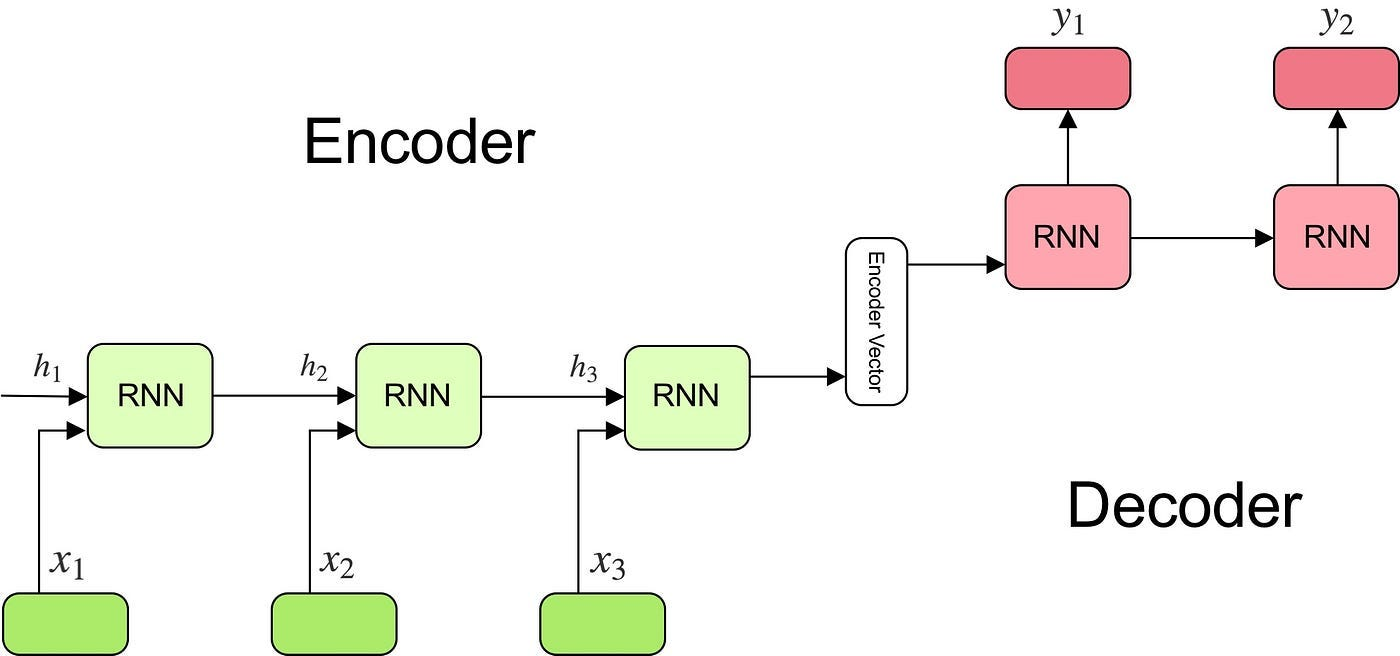

https://towardsdatascience.com/understanding-encoder-decoder-sequence-to-sequence-model-679e04af4346

In [41]:
from keras.models import Model
from keras.layers import Input, Embedding, SimpleRNN, Dense

# Define the input sequence and dimensions
max_features = 10000
input_length = 500
embedding_dim = 32
hidden_units = 32

# Encoder
encoder_inputs = Input(shape=(input_length,))
encoder_embedding = Embedding(input_dim=max_features, output_dim=embedding_dim)(encoder_inputs)
encoder_rnn, encoder_state = SimpleRNN(hidden_units, return_state=True)(encoder_embedding)

# Decoder
decoder_inputs = Input(shape=(input_length,))
decoder_embedding = Embedding(input_dim=max_features, output_dim=embedding_dim)(decoder_inputs)
decoder_rnn = SimpleRNN(hidden_units, return_sequences=True)(decoder_embedding, initial_state=encoder_state)
decoder_outputs = Dense(max_features, activation='softmax')(decoder_rnn)

# Define the model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [42]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 500, 32)   │    320,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 500, 32)   │    320,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_1        │ [(None, 32),      │      2,080 │ embedding_1[0][0] │
│ (SimpleRNN)         │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_2        │ (None, 500, 32)   │      2,080 │ embedding_2[0][0… │
│ (SimpleRNN)         │                   │            │ simple_rnn_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 500,       │    330,000 │ simple_rnn_2[0][… │
│                     │ 10000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 974,160 (3.72 MB)

 Trainable params: 974,160 (3.72 MB)

 Non-trainable params: 0 (0.00 B)